In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Conv2d, BatchNorm2d, SiLU, Identity, Module, Sequential
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
from transformers import T5Tokenizer, T5EncoderModel
import matplotlib.pyplot as plt
import math
device = "cuda"

In [114]:

class MNISTWithTextLabels(Dataset):
    def __init__(self, train=True):
        self.data = datasets.MNIST(
            root="./data",
            train=train,
            download=True,
            transform=ToTensor()
        )
        self.label_to_text = {
            0: "zero",
            1: "one",
            2: "two",
            3: "three",
            4: "four",
            5: "five",
            6: "six",
            7: "seven",
            8: "eight",
            9: "nine",
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]
        text_label = self.label_to_text[int(label)]
        return image, text_label


def get_mnist_dataloaders(batch_size=64):
    train_dataset = MNISTWithTextLabels(train=True)
    test_dataset = MNISTWithTextLabels(train=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader


train_loader, test_loader = get_mnist_dataloaders(batch_size=64)

images, text_labels = next(iter(train_loader))

print(f"Feature batch shape: {images.shape}")
print(f"Labels batch length: {len(text_labels)}")
print(text_labels[:10])

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch length: 64
('four', 'two', 'three', 'eight', 'one', 'eight', 'three', 'two', 'five', 'two')


In [115]:
class Conv(Sequential):
    def __init__(self, cin, cout, k=3, norm=True, act="silu"):
        super().__init__(
        BatchNorm2d(cin) if norm else Identity(),
        Conv2d(cin, cout, k, padding="same"),
        {"none": Identity(), "silu":SiLU()}[act]
        )
class DoubleConv(Module):
    def __init__(self, cin, cout, act="silu"):
        super().__init__()
        self.conv1 = Conv(cin, cout, act=act)
        self.proj = nn.Linear(512, cout)
        self.conv2 = Conv(cout * 2, cout, act=act)
    
    def forward(self, x, vec):
        x = self.conv1(x)
        
        v = self.proj(vec)
        v = v.view(v.shape[0], v.shape[1], 1, 1).repeat(1, 1, x.shape[2], x.shape[3])
        x = torch.cat([x, v], dim=1)

        x = self.conv2(x)

        return x
        
class MultiHeadAttention(Module):
    def __init__(self, embed_size, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)

        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x, mask=None):
        N, seq_len, embed_size = x.shape
        
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        
        q = q.view(N, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(N, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(N, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        out, _ = scaled_product_dot_attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(N, seq_len, embed_size)
        return fc_out(out)

tokenizer = T5Tokenizer.from_pretrained("t5-small")
t5 = T5EncoderModel.from_pretrained("t5-small").to(device)

In [116]:
class UNET(Module):
    def __init__(self, c, tokenizer, encoder):
        super().__init__()
        self.tokenizer = tokenizer
        self.encoder = encoder
        self.cross_attention = MultiHeadAttention(128, 8)
        self.d1 = DoubleConv(2, c)
        self.d2 = DoubleConv(c, c*2)
        self.d3 = DoubleConv(c*2, c*4)

        self.bn = DoubleConv(c*4, c*4)

        self.u3 = DoubleConv(c*8, c*2)
        self.u2 = DoubleConv(c*4, c)
        self.u1 = DoubleConv(c*2, c)
        self.u0 = DoubleConv(c, 1, act="none")

    def forward(self, x, texts):
        tokens = self.tokenizer(texts, padding="max_length", max_length=128, return_tensors="pt").to(device)
        emb = self.encoder.get_input_embeddings()(tokens.input_ids).mean(1)
        
        x = F.pad(x, [2,2,2,2])
        x1 = F.max_pool2d(self.d1(x, emb), 2, 2)
        x2 = F.max_pool2d(self.d2(x1, emb), 2, 2)
        x3 = F.max_pool2d(self.d3(x2, emb), 2, 2)

        x = self.bn(x3, emb)

        x = F.interpolate(self.u3(torch.cat([x3, x], dim=1), emb), scale_factor=2)
        x = F.interpolate(self.u2(torch.cat([x2, x], dim=1), emb), scale_factor=2)
        x = F.interpolate(self.u1(torch.cat([x1, x], dim=1), emb), scale_factor=2)
        x = self.u0(x, emb)
        x = F.pad(x, [-2,-2,-2,-2])
        return x

In [117]:
unet = UNET(16, tokenizer, t5).cuda()
r = torch.randn(1,2,28,28).cuda()
print(unet(r, "femboy is so zesty").shape)
#unet.compile()
optim = torch.optim.Adam(unet.parameters(), fused=True)

torch.Size([1, 1, 28, 28])


In [ ]:
def train_epoch(unet, loader, optimizer, epoch):
    unet.train()
    losses = []
    for x, label in loader:
        x = x.cuda()

        eps = torch.randn_like(x)
        t = torch.rand(len(x), 1, 1, 1, device='cuda')
        z = x * (1 - t) + eps * t
        y = eps - x
        
        zt = torch.cat((z, t.repeat(1, 1, 28, 28)), dim=1)
        y_hat = unet(zt, label)
        loss = (y - y_hat).pow(2).mean()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        
    plt.figure(None, (5, 1))
    plt.xticks([])
    plt.title(f"epoch {epoch+1}")
    plt.plot(losses)
    plt.show()

for g in optim.param_groups:
    g['lr'] = 67e-4 / 2
for epoch in range(670):
    train_epoch(unet, train_loader, optim, epoch)

In [ ]:
save_path = f"model.pth"
torch.save(unet.state_dict(), save_path)

print(f"Model successfully saved to {save_path}")


211777


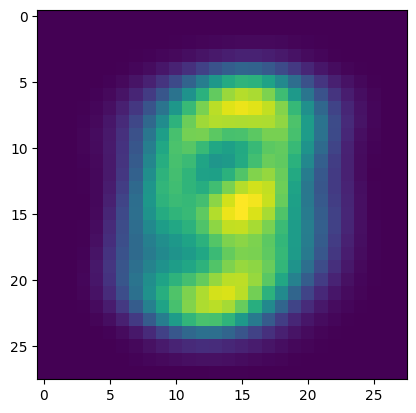

In [23]:
m = []
for x, _ in train_loader:
    m.append(x)
m = torch.cat(m)
plt.imshow(m.mean(dim=0)[0])
print(sum(p.numel() for p in unet.parameters()))

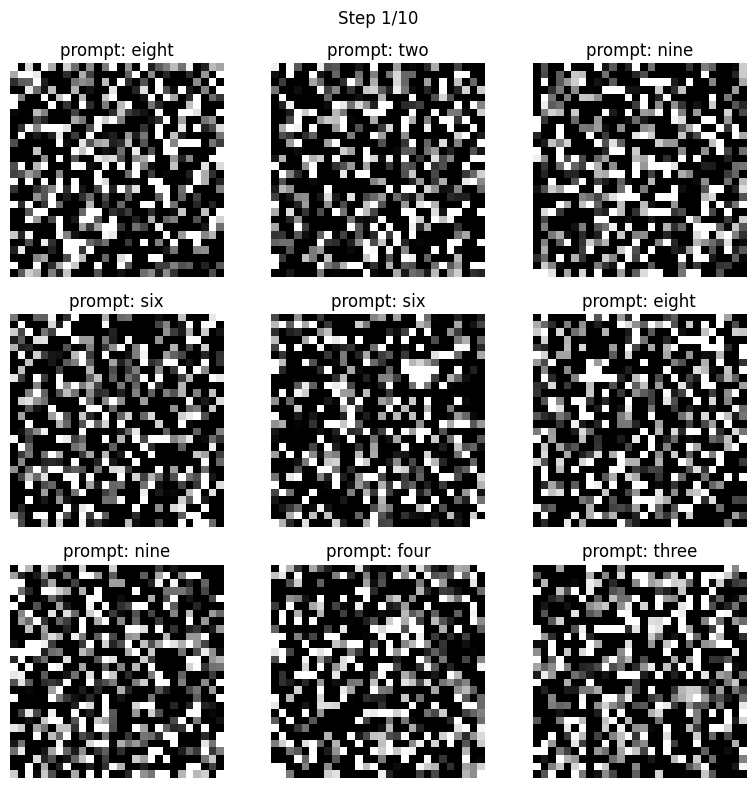

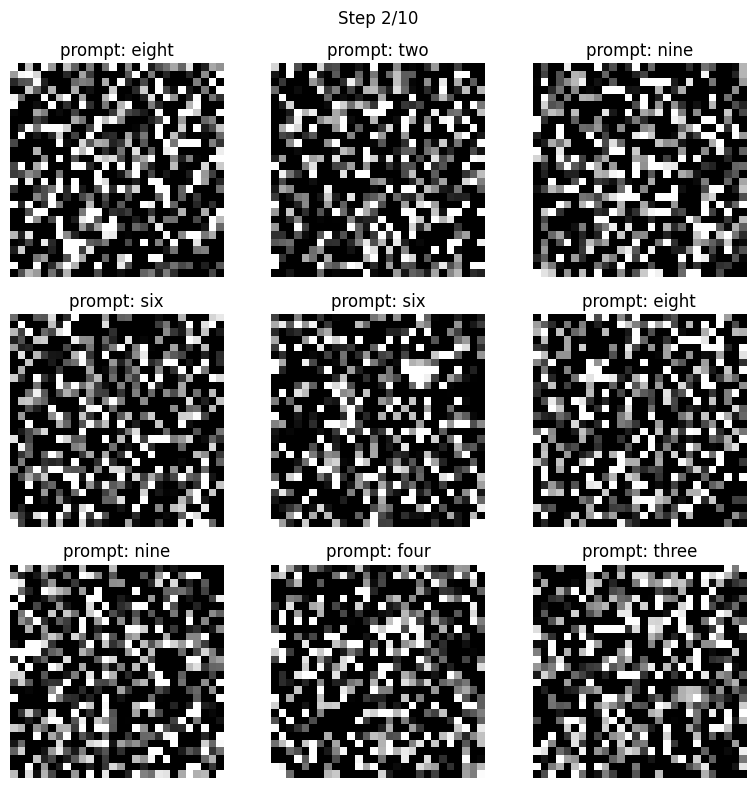

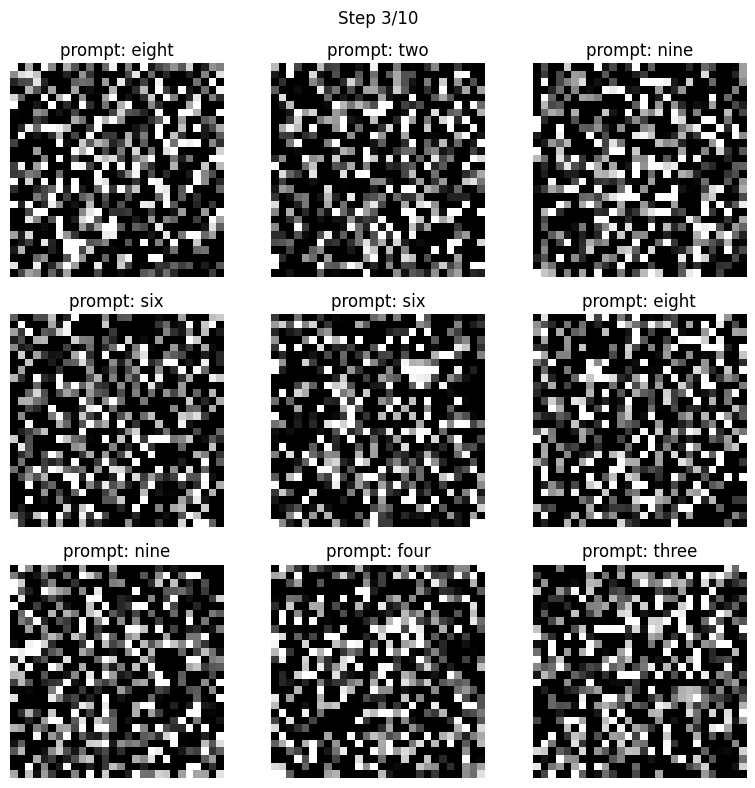

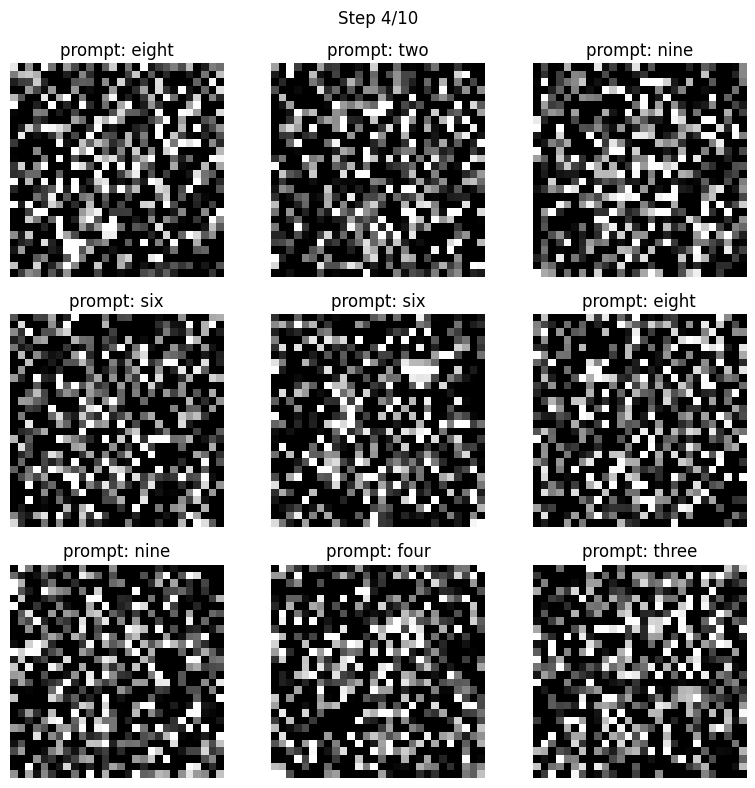

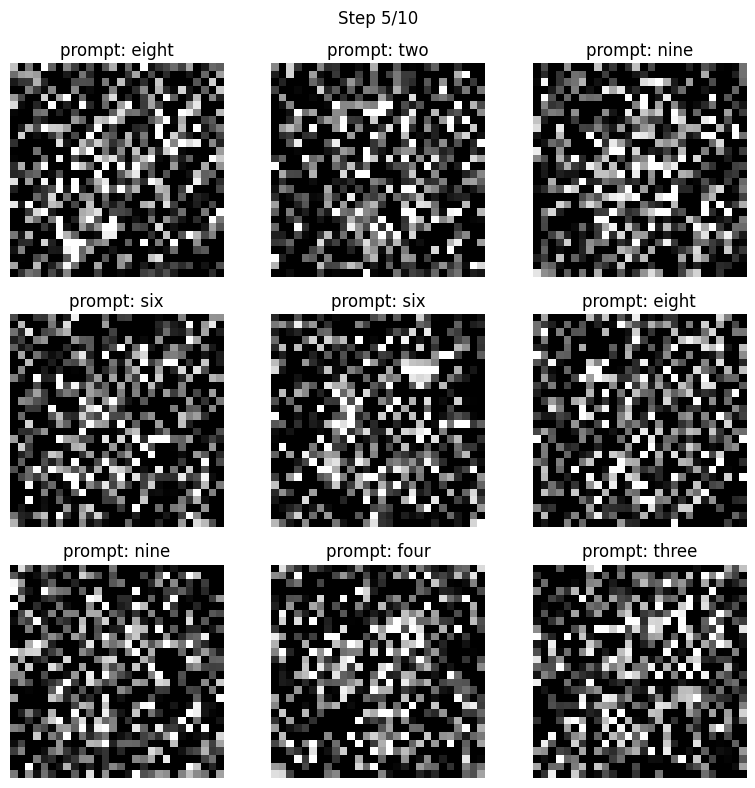

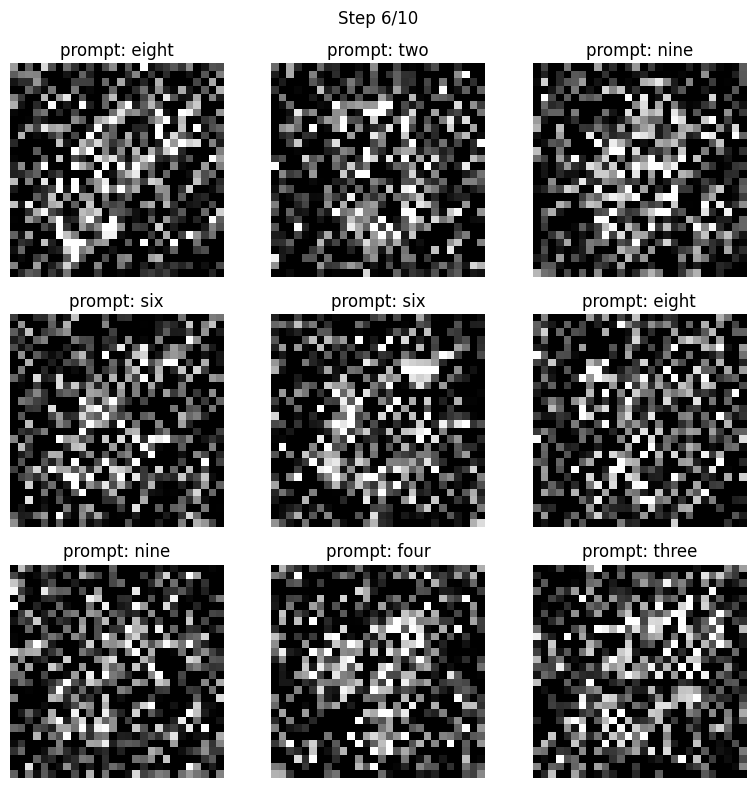

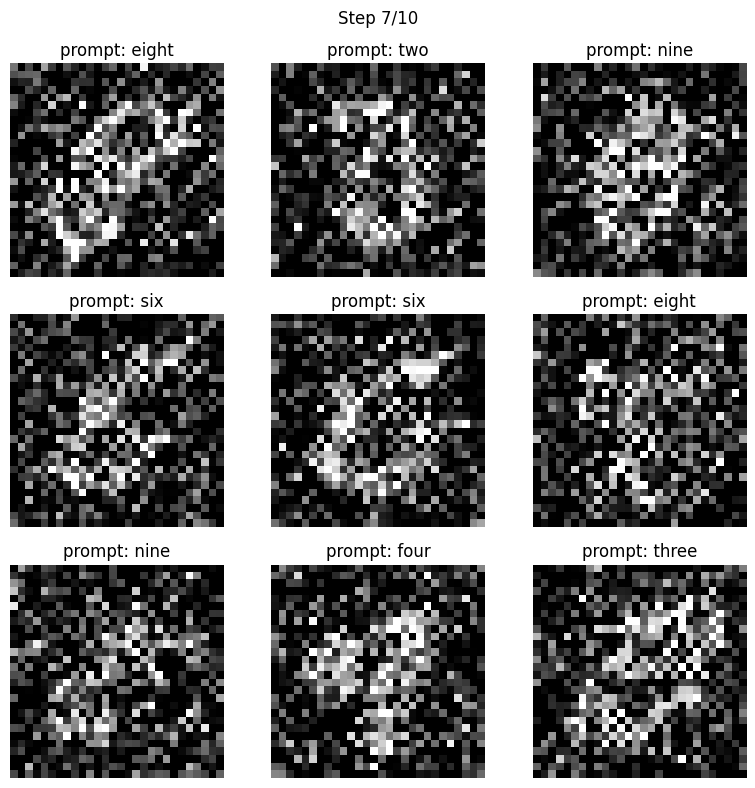

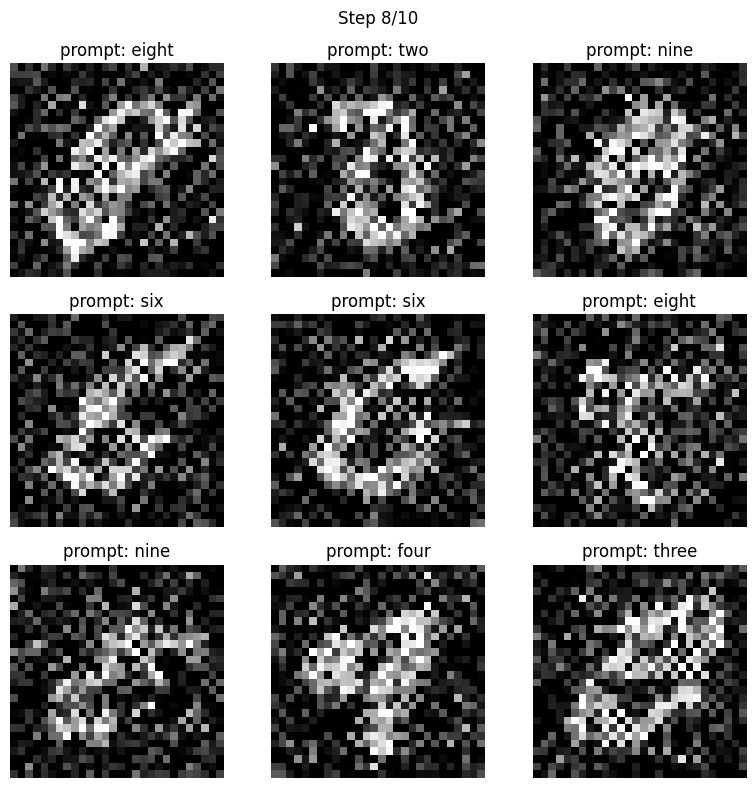

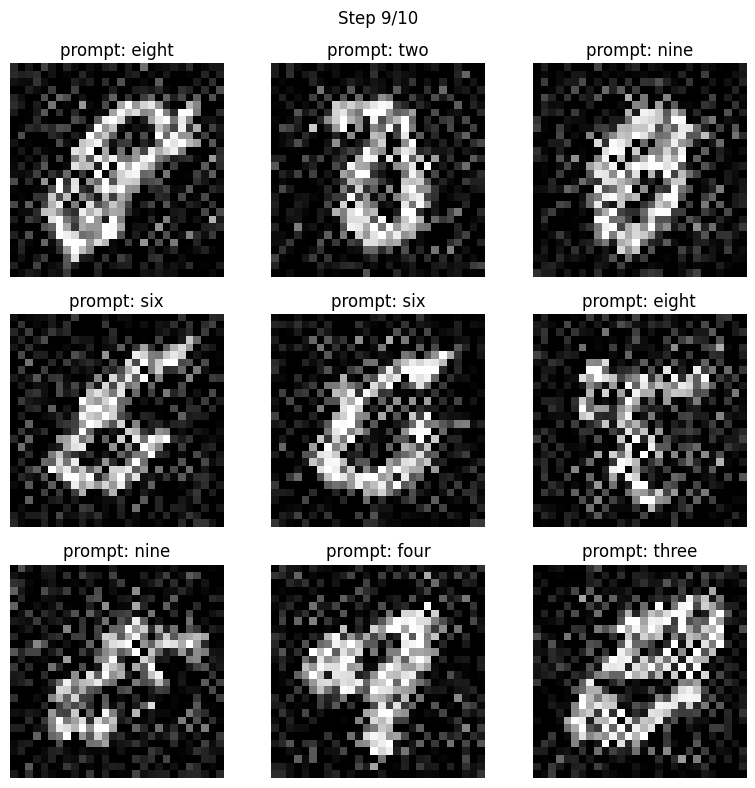

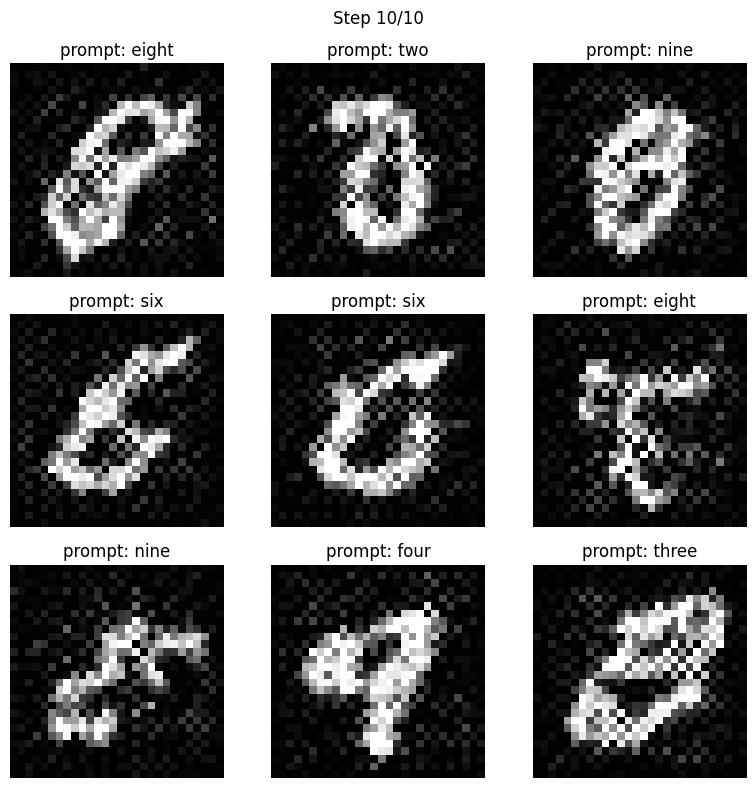

In [131]:
label_to_text = {
            0: "zero",
            1: "one",
            2: "two",
            3: "three",
            4: "four",
            5: "five",
            6: "six",
            7: "seven",
            8: "eight",
            9: "nine",
        }

def generate_mnist_steps_grid(unet, num_samples=16, steps=20):
    unet.eval()

    x_t = torch.randn((num_samples, 1, 28, 28), device=device)

    c_labels = torch.randint(
        low=0,
        high=10,
        size=(num_samples,),
        device=device
    )

    ts = torch.linspace(1.0, 0.0, steps + 1, device=device)

    labels = c_labels.detach().cpu().tolist()
    labels = [label_to_text[d] for d in labels]

    nrow = int(math.sqrt(num_samples))
    ncol = math.ceil(num_samples / nrow)

    for step_idx, (t_from, t_to) in enumerate(zip(ts[:-1], ts[1:]), start=1):
        t = torch.full((num_samples, 1, 28, 28), t_from, device=device)

        zt = torch.cat((x_t, t), dim=1)

        with torch.no_grad():
            sigma = unet(zt, labels)

        x_t = x_t.detach()


        x_0 = x_t - t_from * sigma
        x_0 = x_0.clamp(0, 1)

        sigma = (x_t - x_0) / t_from

        x_t = x_t + sigma * (t_to - t_from)

        imgs = x_t.detach().cpu().clamp(0, 1)

        fig, axes = plt.subplots(nrow, ncol, figsize=(8, 8))
        axes = axes.flatten()

        for i in range(num_samples):
            axes[i].imshow(imgs[i, 0], cmap="gray")
            axes[i].set_title(f"prompt: {labels[i]}")
            axes[i].axis("off")

        for i in range(num_samples, len(axes)):
            axes[i].axis("off")

        fig.suptitle(f"Step {step_idx}/{steps}")
        plt.tight_layout()
        plt.show()

    return x_t, c_labels


x_final, labels = generate_mnist_steps_grid(
    unet,
    num_samples=9,
    steps=10
)